# Global-zone beam radius versus wavelength

This notebook reads the MATLAB v7.3 files produced by ITI_Optics_Profiling_G, selects the frame nearest a user-specified physical height, and fits Gaussian intensity profiles through the beam peak for every wavelength folder.

The source MAT files are opened read-only. Only one requested height slice is loaded from each large three-dimensional stack, so the workflow does not require loading several gigabytes into memory.

The reported radius follows the convention used in the MATLAB code:

\[
I(u)=C+A\exp\left[-\frac{(u-u_0)^2}{2\sigma^2}\right]
    =C+A\exp\left[-\frac{2(u-u_0)^2}{w^2}\right],\qquad w=2\sigma.
\]

Thus, beam radius means the 1/e² intensity radius, not sigma or FWHM. Axial (x) and radial (y) radii are reported separately.

In [1]:
from dataclasses import dataclass
from pathlib import Path
from typing import Optional, Sequence
import warnings

import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from IPython.display import display

# Publication defaults: Arial, 18 pt, editable TrueType text in PDF/PS.
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "axes.linewidth": 1.2,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "legend.fontsize": 18,
    "lines.linewidth": 2.0,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## User settings

Edit HEIGHT_UM and rerun the notebook. The closest measured height is selected independently for each wavelength, matching the MATLAB behavior. FIT_HALF_WIDTH_UM controls the interval around the detected peak used by each one-dimensional fit.

The notebook first looks for the portable HDF5 file beside it. If present, collaborators do not need the original Google Drive tree or MATLAB. Set CREATE_OR_REFRESH_PORTABLE_DATA = True only when creating a fresh portable file from the original MAT files.

PEAK_SEARCH_BOUNDS_UM may be set to a central region if a bright reflection elsewhere in a frame is being mistaken for the beam. Leave it as None to reproduce the MATLAB full-frame peak search. PROFILE_AVERAGE_HALF_WIDTH_PX = 0 uses a single row and column, also matching MATLAB; a value of 1 or 2 can reduce camera noise.

In [2]:
DATA_ROOT = Path(
    "/Users/yiyangzhi/Library/CloudStorage/GoogleDrive-yiyang_zhi3@berkeley.edu/"
    "My Drive/Ming Wu Integrated Photonics Group/Experiments/Measurements/"
    "3-6-ba2-processed_re/Global"
)

# Keep this HDF5 file next to the notebook when sharing it.
PORTABLE_DATA_PATH = Path("global_zone_portable.h5")
PREFER_PORTABLE_DATA = True
CREATE_OR_REFRESH_PORTABLE_DATA = False  # set True only to rebuild from original MAT files
PORTABLE_X_BLOCK_SIZE = 32               # limits export memory use

HEIGHT_UM = 90.0
WAVELENGTHS_NM = None          # None means every numeric wavelength folder
FIT_HALF_WIDTH_UM = 25.0       # symmetric fit interval around the detected peak
IMAGE_HALF_WIDTH_UM = 25.0     # display window only; does not affect fitting
PROFILE_AVERAGE_HALF_WIDTH_PX = 0
PEAK_SEARCH_BOUNDS_UM = None   # e.g. {"x": (-20, 20), "y": (-20, 20)}
R2_WARNING_THRESHOLD = 0.90

EXPORT_CSV = False
EXPORT_PATH = Path("global_zone_beam_radii.csv")
EXPORT_FIGURES = True
FIGURE_OUTPUT_DIR = Path("figures")
FIGURE_DPI = 300

## MATLAB v7.3 reader

These files contain a serialized MATLAB class object rather than a flat dictionary. The reference names inside the HDF5 container are implementation details, so the loader identifies the normalized stack and coordinate vectors using their shapes, monotonicity, ranges, and normalization. Each inferred mapping is validated before analysis.

In [3]:
@dataclass
class ScanSlice:
    wavelength_nm: int
    mat_path: Path
    requested_height_um: float
    selected_height_um: float
    height_index: int
    heights_um: np.ndarray
    x_um: np.ndarray
    y_um: np.ndarray
    frame: np.ndarray
    stack_dataset: str


def discover_mat_files(root: Path, wavelengths: Optional[Sequence[int]] = None):
    root = Path(root).expanduser()
    if not root.is_dir():
        raise FileNotFoundError(f"Measurement root not found: {root}")

    requested = None if wavelengths is None else {int(w) for w in wavelengths}
    found = {}
    for folder in root.iterdir():
        if not folder.is_dir():
            continue
        try:
            wavelength = int(folder.name)
        except ValueError:
            continue
        if requested is not None and wavelength not in requested:
            continue
        matches = [p for p in folder.iterdir() if p.name.lower() == "imported_frames.mat"]
        if len(matches) == 1:
            found[wavelength] = matches[0]
        elif len(matches) > 1:
            raise RuntimeError(f"Multiple Imported_frames.mat files found in {folder}")

    if requested is not None:
        missing = sorted(requested - set(found))
        if missing:
            raise FileNotFoundError(f"No Imported_frames.mat found for wavelengths: {missing}")
    if not found:
        raise FileNotFoundError(f"No wavelength MAT files found below {root}")
    return dict(sorted(found.items()))


def _numeric_datasets(group):
    datasets = []

    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            try:
                is_numeric = np.issubdtype(obj.dtype, np.number)
            except TypeError:
                is_numeric = False
            if is_numeric:
                datasets.append((name, obj))

    group.visititems(visitor)
    return datasets


def _monotonic_vectors(datasets, max_size=20000):
    vectors = []
    for name, ds in datasets:
        if ds.ndim > 2 or ds.size < 2 or ds.size > max_size:
            continue
        values = np.asarray(ds).squeeze()
        if values.ndim != 1 or not np.all(np.isfinite(values)):
            continue
        differences = np.diff(values.astype(float))
        if np.all(differences > 0) or np.all(differences < 0):
            vectors.append((name, values.astype(float)))
    return vectors


def _sample_stack_max(ds):
    indices = []
    for size in ds.shape:
        indices.append(sorted(set([0, size // 4, size // 2, 3 * size // 4, size - 1])))
    samples = []
    for i in indices[0]:
        for j in indices[1]:
            for k in indices[2]:
                value = float(ds[i, j, k])
                if np.isfinite(value):
                    samples.append(value)
    return max(samples) if samples else np.inf


def _choose_centered_axis(candidates, length):
    matching = [(name, v) for name, v in candidates if len(v) == length]
    if not matching:
        raise RuntimeError(f"Could not find coordinate vector of length {length}")

    def score(item):
        _, values = item
        lo, hi = float(np.min(values)), float(np.max(values))
        crossing_penalty = 0.0 if lo <= 0 <= hi else 1e6
        midpoint_penalty = abs((lo + hi) / 2)
        return crossing_penalty + midpoint_penalty

    return min(matching, key=score)


def _infer_layout(h5):
    refs = h5.get("#refs#", h5)
    datasets = _numeric_datasets(refs)
    stacks = [(name, ds) for name, ds in datasets
              if ds.ndim == 3 and np.issubdtype(ds.dtype, np.floating)]
    if not stacks:
        raise RuntimeError("No floating-point 3D image stack found in MAT file")

    # Z and Znorm have the same largest 3D shape; small RGB/reference images do not.
    shape_counts = {}
    for name, ds in stacks:
        shape_counts.setdefault(ds.shape, []).append((name, ds))
    stack_shape, same_shape = max(
        shape_counts.items(), key=lambda item: (len(item[1]) >= 2, np.prod(item[0]))
    )

    vectors = _monotonic_vectors(datasets)
    height_dim = int(np.argmin(stack_shape))
    n_frames = stack_shape[height_dim]
    height_candidates = [(name, v) for name, v in vectors if len(v) == n_frames]
    if not height_candidates:
        raise RuntimeError(f"Could not find height array of length {n_frames}")

    # Prefer a regularly spaced, increasing, nonnegative physical height axis.
    def height_score(item):
        _, values = item
        dv = np.diff(values)
        regularity = np.std(dv) / max(abs(np.mean(dv)), np.finfo(float).eps)
        direction_penalty = 0 if np.all(dv > 0) else 1e4
        sign_penalty = 0 if np.min(values) >= 0 else 1e3
        return direction_penalty + sign_penalty + regularity + abs(values[0]) * 1e-6

    height_name, heights = min(height_candidates, key=height_score)

    spatial_dims = [dim for dim in range(3) if dim != height_dim]
    # The camera convention used by this class is horizontal x = longer dimension.
    x_dim = max(spatial_dims, key=lambda dim: stack_shape[dim])
    y_dim = min(spatial_dims, key=lambda dim: stack_shape[dim])
    x_name, x_um = _choose_centered_axis(vectors, stack_shape[x_dim])
    y_name, y_um = _choose_centered_axis(vectors, stack_shape[y_dim])

    # The normalized stack has sampled values of order unity; raw Z is camera counts.
    sampled = [(name, ds, _sample_stack_max(ds)) for name, ds in same_shape]
    normalized = [item for item in sampled if 0 < item[2] <= 1.5]
    raw = [item for item in sampled if item[2] > 1.5]
    stack_name, stack_ds, _ = min(normalized or sampled, key=lambda item: item[2])
    raw_name, raw_ds, _ = max(raw or sampled, key=lambda item: item[2])

    return {
        "stack_name": stack_name,
        "stack_ds": stack_ds,
        "raw_name": raw_name,
        "raw_ds": raw_ds,
        "height_name": height_name,
        "heights": heights,
        "height_dim": height_dim,
        "x_name": x_name,
        "x_um": x_um,
        "x_dim": x_dim,
        "y_name": y_name,
        "y_um": y_um,
        "y_dim": y_dim,
    }


def load_scan_slice(wavelength_nm: int, mat_path: Path, requested_height_um: float):
    with h5py.File(mat_path, "r") as h5:
        layout = _infer_layout(h5)
        heights = layout["heights"]
        height_index = int(np.argmin(np.abs(heights - requested_height_um)))

        if requested_height_um < heights.min() or requested_height_um > heights.max():
            warnings.warn(
                f"{wavelength_nm} nm: requested height {requested_height_um:g} um lies outside "
                f"[{heights.min():g}, {heights.max():g}] um; using nearest frame."
            )

        selector = [slice(None)] * 3
        selector[layout["height_dim"]] = height_index
        stored_frame = np.asarray(layout["stack_ds"][tuple(selector)], dtype=float)
        remaining_dims = [dim for dim in range(3) if dim != layout["height_dim"]]

        if remaining_dims == [layout["x_dim"], layout["y_dim"]]:
            frame = stored_frame.T
        elif remaining_dims == [layout["y_dim"], layout["x_dim"]]:
            frame = stored_frame
        else:
            raise RuntimeError("Unexpected HDF5 spatial-axis ordering")

        x_um = np.asarray(layout["x_um"], dtype=float)
        y_um = np.asarray(layout["y_um"], dtype=float)
        if frame.shape != (len(y_um), len(x_um)):
            raise RuntimeError(
                f"Frame/axis mismatch: frame {frame.shape}, y {len(y_um)}, x {len(x_um)}"
            )
        if not np.isfinite(frame).any() or np.nanmax(frame) > 1.5 or np.nanmin(frame) < -1e-9:
            raise RuntimeError("Inferred image stack does not appear to be normalized Znorm")

        return ScanSlice(
            wavelength_nm=int(wavelength_nm),
            mat_path=Path(mat_path),
            requested_height_um=float(requested_height_um),
            selected_height_um=float(heights[height_index]),
            height_index=height_index,
            heights_um=np.asarray(heights, dtype=float),
            x_um=x_um,
            y_um=y_um,
            frame=frame,
            stack_dataset=layout["stack_name"],
        )


def load_portable_slices(portable_path, requested_height_um, wavelengths=None):
    portable_path = Path(portable_path)
    requested = None if wavelengths is None else {int(w) for w in wavelengths}
    scans = {}
    with h5py.File(portable_path, "r") as h5:
        available = sorted(int(name) for name in h5.keys() if name.isdigit())
        selected_wavelengths = available if requested is None else sorted(requested)
        missing = sorted(set(selected_wavelengths) - set(available))
        if missing:
            raise KeyError(f"Portable file is missing wavelengths: {missing}")

        for wavelength in selected_wavelengths:
            group = h5[str(wavelength)]
            heights = np.asarray(group["height_um"], dtype=float)
            x_um = np.asarray(group["x_um"], dtype=float)
            y_um = np.asarray(group["y_um"], dtype=float)
            height_index = int(np.argmin(np.abs(heights - requested_height_um)))
            scale = float(group["raw_counts"].attrs["normalization_max_counts"])
            frame = np.asarray(group["raw_counts"][height_index], dtype=np.float32) / scale
            scans[wavelength] = ScanSlice(
                wavelength_nm=wavelength,
                mat_path=portable_path,
                requested_height_um=float(requested_height_um),
                selected_height_um=float(heights[height_index]),
                height_index=height_index,
                heights_um=heights,
                x_um=x_um,
                y_um=y_um,
                frame=frame,
                stack_dataset=f"/{wavelength}/raw_counts",
            )
            print(
                f"  {wavelength} nm: selected {heights[height_index]:g} µm "
                f"(index {height_index}); frame shape {frame.shape}"
            )
    return scans


def export_portable_dataset(root, output_path, wavelengths=None, x_block_size=32,
                            overwrite=False):
    """Export exact camera counts and coordinates to a simple, portable HDF5 file.

    The source Z arrays contain integer camera counts stored as doubles. Counts are
    saved losslessly as uint16. Znorm is reconstructed exactly as counts/global_max.
    Destination chunks are one height deep, making arbitrary-height exploration fast.
    """
    output_path = Path(output_path)
    if output_path.exists() and not overwrite:
        print(f"Portable dataset already exists: {output_path.resolve()}")
        return output_path

    files = discover_mat_files(root, wavelengths)
    temporary_path = output_path.with_suffix(output_path.suffix + ".partial")
    if temporary_path.exists():
        temporary_path.unlink()

    try:
        with h5py.File(temporary_path, "w") as destination:
            destination.attrs["format"] = "global_zone_portable_v1"
            destination.attrs["layout"] = "height, y, x"
            destination.attrs["intensity_definition"] = (
                "normalized_intensity = raw_counts / normalization_max_counts"
            )
            destination.attrs["lossless"] = True

            for wavelength, mat_path in files.items():
                print(f"Exporting {wavelength} nm from {mat_path.name} ...", flush=True)
                with h5py.File(mat_path, "r") as source:
                    layout = _infer_layout(source)
                    raw_ds = layout["raw_ds"]
                    heights = np.asarray(layout["heights"], dtype=float)
                    x_um = np.asarray(layout["x_um"], dtype=float)
                    y_um = np.asarray(layout["y_um"], dtype=float)
                    n_height, ny, nx = len(heights), len(y_um), len(x_um)

                    group = destination.create_group(str(wavelength))
                    group.attrs["wavelength_nm"] = wavelength
                    group.attrs["source_mat_file"] = str(mat_path)
                    group.create_dataset("height_um", data=heights)
                    group.create_dataset("x_um", data=x_um)
                    group.create_dataset("y_um", data=y_um)
                    counts_ds = group.create_dataset(
                        "raw_counts",
                        shape=(n_height, ny, nx),
                        dtype=np.uint16,
                        chunks=(1, min(256, ny), min(x_block_size, nx)),
                        compression="gzip",
                        compression_opts=4,
                        shuffle=True,
                        fletcher32=True,
                    )

                    maximum_count = 0
                    for x_start in range(0, nx, x_block_size):
                        x_stop = min(nx, x_start + x_block_size)
                        selector = [slice(None)] * 3
                        selector[layout["x_dim"]] = slice(x_start, x_stop)
                        block = np.asarray(raw_ds[tuple(selector)], dtype=float)
                        ordered = np.transpose(
                            block,
                            axes=[layout["height_dim"], layout["y_dim"], layout["x_dim"]],
                        )
                        rounded = np.rint(ordered)
                        if np.nanmax(np.abs(ordered - rounded)) > 1e-8:
                            raise ValueError("Raw camera data are not integral as expected")
                        block_max = int(np.nanmax(rounded))
                        if np.nanmin(rounded) < 0 or block_max > np.iinfo(np.uint16).max:
                            raise ValueError("Camera counts fall outside uint16 range")
                        maximum_count = max(maximum_count, block_max)
                        counts_ds[:, :, x_start:x_stop] = rounded.astype(np.uint16)
                        print(
                            f"  x pixels {x_start:4d}:{x_stop:4d} / {nx}",
                            end="\r",
                            flush=True,
                        )
                    counts_ds.attrs["normalization_max_counts"] = maximum_count
                    counts_ds.attrs["units"] = "camera counts"
                    print(f"  completed; global maximum = {maximum_count} counts")

        temporary_path.replace(output_path)
    except Exception:
        if temporary_path.exists():
            temporary_path.unlink()
        raise

    print(f"Portable dataset saved to {output_path.resolve()}")
    return output_path


def load_all_slices(root, requested_height_um, wavelengths=None,
                    portable_path=None, prefer_portable=True):
    if portable_path is not None and prefer_portable and Path(portable_path).is_file():
        print(f"Loading portable dataset: {Path(portable_path).resolve()}")
        return load_portable_slices(portable_path, requested_height_um, wavelengths)

    files = discover_mat_files(root, wavelengths)
    scans = {}
    for wavelength, path in files.items():
        print(f"Loading {wavelength} nm at the frame nearest {requested_height_um:g} µm ...", flush=True)
        scans[wavelength] = load_scan_slice(wavelength, path, requested_height_um)
        scan = scans[wavelength]
        print(
            f"  selected {scan.selected_height_um:g} µm (index {scan.height_index}); "
            f"frame shape {scan.frame.shape}"
        )
    return scans


## Portable collaborator data

The export contains every measured height for every wavelength, not only the currently displayed frame. It uses a documented HDF5 layout of wavelength/height/y/x and stores the original integer camera counts losslessly. Normalized intensity is reconstructed using the saved global-maximum count, exactly matching MATLAB Znorm.

Share global_zone.ipynb and global_zone_portable.h5 together. A collaborator can change HEIGHT_UM and run the notebook without your Google Drive paths. HDF5 is readable from Python, MATLAB, Julia, and many other tools.

In [4]:
if CREATE_OR_REFRESH_PORTABLE_DATA:
    export_portable_dataset(
        DATA_ROOT,
        PORTABLE_DATA_PATH,
        wavelengths=WAVELENGTHS_NM,
        x_block_size=PORTABLE_X_BLOCK_SIZE,
        overwrite=True,
    )

In [5]:
scans = load_all_slices(
    DATA_ROOT,
    HEIGHT_UM,
    WAVELENGTHS_NM,
    portable_path=PORTABLE_DATA_PATH,
    prefer_portable=PREFER_PORTABLE_DATA,
)

scan_summary = pd.DataFrame([
    {
        "wavelength_nm": scan.wavelength_nm,
        "selected_height_um": scan.selected_height_um,
        "height_step_um": float(np.median(np.diff(scan.heights_um))),
        "height_range_um": f"{scan.heights_um.min():g} to {scan.heights_um.max():g}",
        "frame_shape_yx": str(scan.frame.shape),
        "x_range_um": f"{scan.x_um.min():.2f} to {scan.x_um.max():.2f}",
        "y_range_um": f"{scan.y_um.min():.2f} to {scan.y_um.max():.2f}",
        "source_data_file": str(scan.mat_path),
    }
    for scan in scans.values()
]).set_index("wavelength_nm")

display(scan_summary)

Loading portable dataset: /Users/yiyangzhi/GIT/integrated_trapped_ions/Analysis/global_zone_portable.h5
  450 nm: selected 90 µm (index 89); frame shape (1024, 1280)
  515 nm: selected 90 µm (index 89); frame shape (1024, 1280)
  635 nm: selected 90 µm (index 89); frame shape (1024, 1280)


,selected_height_um,height_step_um,height_range_um,frame_shape_yx,x_range_um,y_range_um,source_data_file
wavelength_nm,,,,,,,
450,90.0,1.0,1 to 200,"(1024, 1280)",-70.22 to 70.51,-48.18 to 66.74,global_zone_portable.h5
515,90.0,1.0,1 to 200,"(1024, 1280)",-69.88 to 70.17,-48.64 to 65.41,global_zone_portable.h5
635,90.0,1.0,1 to 200,"(1024, 1280)",-70.39 to 69.78,-48.02 to 66.19,global_zone_portable.h5


## Gaussian fitting

The peak is found in the full frame unless PEAK_SEARCH_BOUNDS_UM is supplied. The axial profile is the row through that peak; the radial profile is the column through it. Optional neighboring-row/column averaging is symmetric and affects only noise, not the coordinate scale.

The fit uses bounded nonlinear least squares with nonnegative amplitude, width, and background. The radius uncertainty is 2 times the one-standard-deviation covariance estimate for sigma. This is a formal statistical uncertainty conditional on the Gaussian model; structured backgrounds and flat-topped profiles can cause larger systematic error, so R² and the diagnostic plots should always be reviewed.

In [6]:
@dataclass
class ProfileFit:
    axis: str
    coordinate_um: np.ndarray
    intensity: np.ndarray
    fit_mask: np.ndarray
    fitted_intensity: np.ndarray
    amplitude: float
    center_um: float
    sigma_um: float
    offset: float
    radius_um: float
    radius_std_um: float
    r_squared: float
    rmse: float
    status: str


@dataclass
class ScanFit:
    scan: ScanSlice
    peak_x_um: float
    peak_y_um: float
    peak_intensity: float
    axial: ProfileFit
    radial: ProfileFit


def gaussian_intensity(u, amplitude, center, sigma, offset):
    return offset + amplitude * np.exp(-0.5 * ((u - center) / sigma) ** 2)


def locate_peak(scan: ScanSlice, bounds=None):
    mask = np.isfinite(scan.frame)
    if bounds is not None:
        x_bounds = bounds.get("x", (-np.inf, np.inf))
        y_bounds = bounds.get("y", (-np.inf, np.inf))
        mask &= (
            (scan.x_um[None, :] >= min(x_bounds))
            & (scan.x_um[None, :] <= max(x_bounds))
            & (scan.y_um[:, None] >= min(y_bounds))
            & (scan.y_um[:, None] <= max(y_bounds))
        )
    if not np.any(mask):
        raise ValueError(f"{scan.wavelength_nm} nm: peak-search region contains no pixels")
    searchable = np.where(mask, scan.frame, -np.inf)
    return np.unravel_index(np.argmax(searchable), searchable.shape)


def extract_profiles(scan: ScanSlice, peak_row: int, peak_col: int, average_half_width_px=0):
    half = int(average_half_width_px)
    if half < 0:
        raise ValueError("PROFILE_AVERAGE_HALF_WIDTH_PX must be nonnegative")
    row_slice = slice(max(0, peak_row - half), min(scan.frame.shape[0], peak_row + half + 1))
    col_slice = slice(max(0, peak_col - half), min(scan.frame.shape[1], peak_col + half + 1))
    axial = np.nanmean(scan.frame[row_slice, :], axis=0)
    radial = np.nanmean(scan.frame[:, col_slice], axis=1)
    return axial, radial


def fit_profile(axis_name, coordinate_um, intensity, peak_coordinate_um,
                fit_half_width_um, r2_warning_threshold):
    coordinate_um = np.asarray(coordinate_um, dtype=float)
    intensity = np.asarray(intensity, dtype=float)
    fit_mask = (
        np.isfinite(coordinate_um)
        & np.isfinite(intensity)
        & (np.abs(coordinate_um - peak_coordinate_um) <= fit_half_width_um)
    )
    x_fit = coordinate_um[fit_mask]
    y_fit = intensity[fit_mask]
    if len(x_fit) < 8:
        raise ValueError(f"{axis_name}: fewer than eight points in fit window")

    dx = float(np.median(np.abs(np.diff(x_fit))))
    n_edge = max(3, len(y_fit) // 10)
    edge_values = np.concatenate([y_fit[:n_edge], y_fit[-n_edge:]])
    offset0 = float(np.clip(np.percentile(edge_values, 20), 0, np.max(y_fit)))
    weights = np.clip(y_fit - offset0, 0, None)
    if np.sum(weights) > 0:
        center0 = float(np.sum(x_fit * weights) / np.sum(weights))
        sigma0 = float(np.sqrt(np.sum(weights * (x_fit - center0) ** 2) / np.sum(weights)))
    else:
        center0 = float(peak_coordinate_um)
        sigma0 = float(fit_half_width_um / 3)

    center0 = float(np.clip(center0, x_fit.min(), x_fit.max()))
    sigma0 = float(np.clip(sigma0, dx, x_fit.ptp() / 2))
    amplitude0 = float(max(np.max(y_fit) - offset0, np.finfo(float).eps))
    upper_amplitude = float(max(2 * np.max(y_fit), 2 * np.ptp(y_fit), 1.0))

    lower = [0.0, x_fit.min(), dx / 4, 0.0]
    upper = [upper_amplitude, x_fit.max(), x_fit.ptp(), np.max(y_fit)]
    params, covariance = curve_fit(
        gaussian_intensity,
        x_fit,
        y_fit,
        p0=[amplitude0, center0, sigma0, offset0],
        bounds=(lower, upper),
        maxfev=50000,
    )
    amplitude, center, sigma, offset = map(float, params)
    fit_values = gaussian_intensity(x_fit, *params)
    residuals = y_fit - fit_values
    ss_res = float(np.sum(residuals ** 2))
    ss_tot = float(np.sum((y_fit - np.mean(y_fit)) ** 2))
    r_squared = np.nan if ss_tot == 0 else 1 - ss_res / ss_tot
    rmse = float(np.sqrt(np.mean(residuals ** 2)))

    parameter_std = np.sqrt(np.clip(np.diag(covariance), 0, None))
    radius = 2 * abs(sigma)
    radius_std = 2 * float(parameter_std[2])

    notes = []
    if not np.isfinite(r_squared) or r_squared < r2_warning_threshold:
        notes.append(f"review: R2 < {r2_warning_threshold:.2f}")
    if radius_std > 0.2 * radius:
        notes.append("large formal uncertainty")
    edge_margin = 0.1 * x_fit.ptp()
    if center < x_fit.min() + edge_margin or center > x_fit.max() - edge_margin:
        notes.append("center near fit-window edge")
    status = "OK" if not notes else "; ".join(notes)

    return ProfileFit(
        axis=axis_name,
        coordinate_um=coordinate_um,
        intensity=intensity,
        fit_mask=fit_mask,
        fitted_intensity=fit_values,
        amplitude=amplitude,
        center_um=center,
        sigma_um=abs(sigma),
        offset=offset,
        radius_um=radius,
        radius_std_um=radius_std,
        r_squared=float(r_squared),
        rmse=rmse,
        status=status,
    )


def fit_scan(scan, fit_half_width_um=15.0, average_half_width_px=0,
             peak_search_bounds=None, r2_warning_threshold=0.90):
    peak_row, peak_col = locate_peak(scan, peak_search_bounds)
    axial_profile, radial_profile = extract_profiles(
        scan, peak_row, peak_col, average_half_width_px
    )
    peak_x = float(scan.x_um[peak_col])
    peak_y = float(scan.y_um[peak_row])
    axial = fit_profile(
        "axial", scan.x_um, axial_profile, peak_x,
        fit_half_width_um, r2_warning_threshold
    )
    radial = fit_profile(
        "radial", scan.y_um, radial_profile, peak_y,
        fit_half_width_um, r2_warning_threshold
    )
    return ScanFit(
        scan=scan,
        peak_x_um=peak_x,
        peak_y_um=peak_y,
        peak_intensity=float(scan.frame[peak_row, peak_col]),
        axial=axial,
        radial=radial,
    )


def fit_all_scans(scans):
    return {
        wavelength: fit_scan(
            scan,
            fit_half_width_um=FIT_HALF_WIDTH_UM,
            average_half_width_px=PROFILE_AVERAGE_HALF_WIDTH_PX,
            peak_search_bounds=PEAK_SEARCH_BOUNDS_UM,
            r2_warning_threshold=R2_WARNING_THRESHOLD,
        )
        for wavelength, scan in scans.items()
    }

In [7]:
fits = fit_all_scans(scans)

result_rows = []
for wavelength, fit in fits.items():
    result_rows.append({
        "wavelength_nm": wavelength,
        "requested_height_um": fit.scan.requested_height_um,
        "selected_height_um": fit.scan.selected_height_um,
        "height_error_um": fit.scan.selected_height_um - fit.scan.requested_height_um,
        "peak_x_um": fit.peak_x_um,
        "peak_y_um": fit.peak_y_um,
        "peak_intensity_norm": fit.peak_intensity,
        "axial_center_um": fit.axial.center_um,
        "axial_radius_um": fit.axial.radius_um,
        "axial_radius_std_um": fit.axial.radius_std_um,
        "axial_R2": fit.axial.r_squared,
        "axial_RMSE": fit.axial.rmse,
        "axial_status": fit.axial.status,
        "radial_center_um": fit.radial.center_um,
        "radial_radius_um": fit.radial.radius_um,
        "radial_radius_std_um": fit.radial.radius_std_um,
        "radial_R2": fit.radial.r_squared,
        "radial_RMSE": fit.radial.rmse,
        "radial_status": fit.radial.status,
    })

results = pd.DataFrame(result_rows).set_index("wavelength_nm").sort_index()

assert len(results) == len(scans)
assert np.all(np.isfinite(results[["axial_radius_um", "radial_radius_um"]]))
assert np.all(results[["axial_radius_um", "radial_radius_um"]].to_numpy() > 0)

display(results.round(4))

,requested_height_um,selected_height_um,height_error_um,peak_x_um,peak_y_um,peak_intensity_norm,axial_center_um,axial_radius_um,axial_radius_std_um,axial_R2,axial_RMSE,axial_status,radial_center_um,radial_radius_um,radial_radius_std_um,radial_R2,radial_RMSE,radial_status
wavelength_nm,,,,,,,,,,,,,,,,,,
450,90.0,90.0,0.0,-17.9546,-0.3283,0.8629,-12.6421,26.7747,1.6166,0.7128,0.1473,review: R2 < 0.90,0.5895,10.8383,0.2862,0.8534,0.0849,review: R2 < 0.90
515,90.0,90.0,0.0,-19.5118,-0.0291,0.8704,-11.4878,27.3067,1.1127,0.8229,0.1194,review: R2 < 0.90,2.9458,36.9792,5.9775,0.5582,0.1295,review: R2 < 0.90
635,90.0,90.0,0.0,-17.6793,-0.1250,0.9073,-17.2642,11.1291,0.1466,0.9580,0.0627,OK,0.8051,8.5748,0.0439,0.9935,0.0250,OK


Saved publication figures to figures/global_zone_beam_fits_90um.pdf and .png


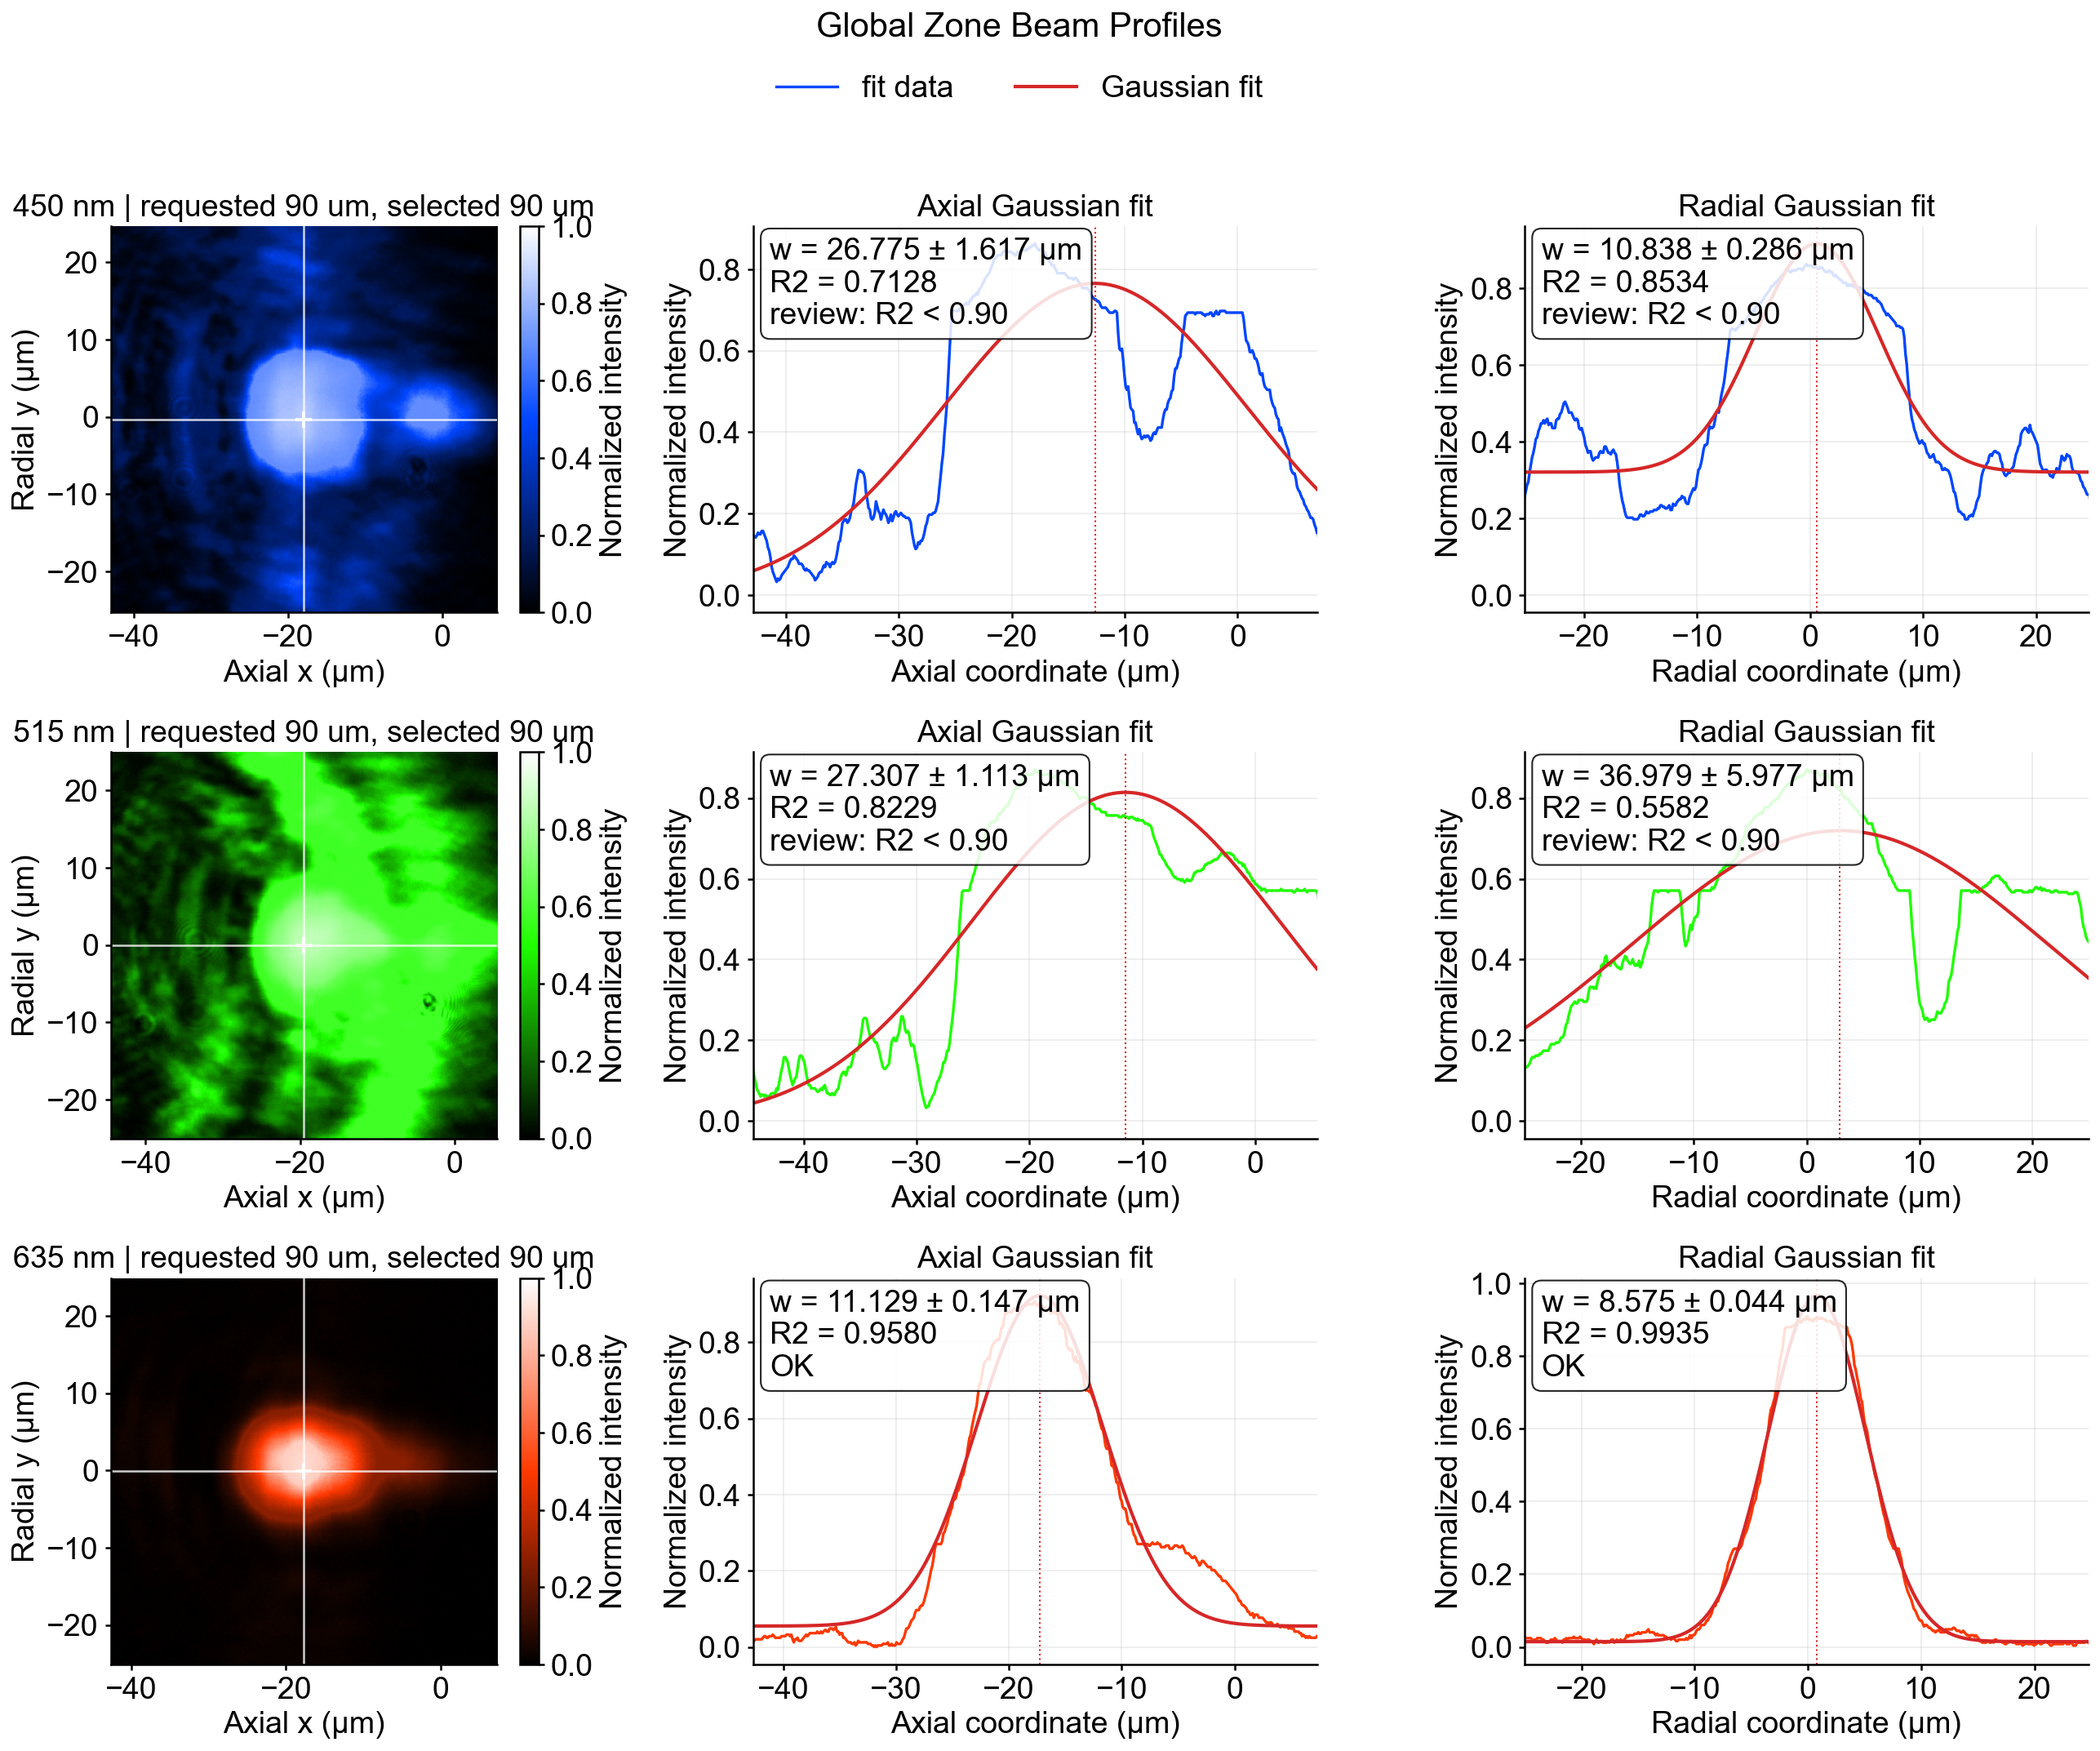

In [8]:
WAVELENGTH_COLORS = {
    405: "#8200c8",
    450: "#0046ff",
    515: "#1fff00",
    635: "#ff3900",
    730: "#b10000",
}


def wavelength_color(wavelength_nm):
    if wavelength_nm in WAVELENGTH_COLORS:
        return WAVELENGTH_COLORS[wavelength_nm]
    normalized = np.clip((wavelength_nm - 380) / (750 - 380), 0, 1)
    return plt.cm.turbo(normalized)


def plot_profile(ax, profile_fit, color):
    x = profile_fit.coordinate_um
    y = profile_fit.intensity
    mask = profile_fit.fit_mask
    x_fit = x[mask]
    ax.plot(x, y, color="0.72", lw=1.2, label="_nolegend_")
    ax.plot(x_fit, y[mask], color=color, lw=1.6, label="fit data")
    dense = np.linspace(x_fit.min(), x_fit.max(), 600)
    ax.plot(
        dense,
        gaussian_intensity(
            dense,
            profile_fit.amplitude,
            profile_fit.center_um,
            profile_fit.sigma_um,
            profile_fit.offset,
        ),
        color="#d62728",
        lw=2.0,
        label="Gaussian fit",
    )
    ax.axvline(profile_fit.center_um, color="#d62728", ls=":", lw=1)
    ax.set_xlim(x_fit.min(), x_fit.max())
    ax.set_xlabel(f"{profile_fit.axis.capitalize()} coordinate (µm)")
    ax.set_ylabel("Normalized intensity")
    ax.grid(alpha=0.25)
    ax.text(
        0.03,
        0.97,
        f"w = {profile_fit.radius_um:.3f} ± {profile_fit.radius_std_um:.3f} µm\n"
        f"R2 = {profile_fit.r_squared:.4f}\n{profile_fit.status}",
        transform=ax.transAxes,
        va="top",
        fontsize=18,
        bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
    )


fig, axes = plt.subplots(len(fits), 3, figsize=(18, 4.8 * len(fits)), squeeze=False)
for row, (wavelength, fit) in enumerate(fits.items()):
    color = wavelength_color(wavelength)
    cmap = LinearSegmentedColormap.from_list(f"wl_{wavelength}", ["black", color, "white"])
    scan = fit.scan
    image_ax, axial_ax, radial_ax = axes[row]

    image = image_ax.imshow(
        scan.frame,
        origin="lower",
        extent=[scan.x_um.min(), scan.x_um.max(), scan.y_um.min(), scan.y_um.max()],
        aspect="equal",
        cmap=cmap,
        vmin=0,
        vmax=1.0,
        interpolation="nearest",
    )
    colorbar = fig.colorbar(image, ax=image_ax, fraction=0.046, pad=0.04)
    colorbar.set_label("Normalized intensity")
    colorbar.set_ticks(np.linspace(0, 1, 6))
    colorbar.ax.tick_params(labelsize=18)
    image_ax.axhline(fit.peak_y_um, color="white", lw=1.2, alpha=0.8)
    image_ax.axvline(fit.peak_x_um, color="white", lw=1.2, alpha=0.8)
    image_ax.plot(fit.peak_x_um, fit.peak_y_um, "+", color="white", ms=10, mew=1.8)
    image_ax.set_xlim(fit.peak_x_um - IMAGE_HALF_WIDTH_UM, fit.peak_x_um + IMAGE_HALF_WIDTH_UM)
    image_ax.set_ylim(fit.peak_y_um - IMAGE_HALF_WIDTH_UM, fit.peak_y_um + IMAGE_HALF_WIDTH_UM)
    image_ax.set_xlabel("Axial x (µm)")
    image_ax.set_ylabel("Radial y (µm)")
    image_ax.set_title(
        f"{wavelength} nm | requested {scan.requested_height_um:g} um, "
        f"selected {scan.selected_height_um:g} um"
    )

    plot_profile(axial_ax, fit.axial, color)
    axial_ax.set_title("Axial Gaussian fit")
    plot_profile(radial_ax, fit.radial, color)
    radial_ax.set_title("Radial Gaussian fit")

handles, labels = axes[0, 1].get_legend_handles_labels()
fig.suptitle("Global Zone Beam Profiles", y=0.998, fontsize=20)
fig.legend(
    handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.978),
    ncol=3, frameon=False,
)
fig.tight_layout(rect=(0, 0, 1, 0.95))

if EXPORT_FIGURES:
    FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    height_tag = f"{HEIGHT_UM:g}".replace(".", "p")
    figure_stem = FIGURE_OUTPUT_DIR / f"global_zone_beam_fits_{height_tag}um"
    fig.savefig(figure_stem.with_suffix(".pdf"))
    fig.savefig(figure_stem.with_suffix(".png"), dpi=FIGURE_DPI)
    print(f"Saved publication figures to {figure_stem}.pdf and .png")

plt.show()

## Compact radius summary and export

Rows marked review should not be treated as reliable single-Gaussian radii without inspecting the plotted profile and adjusting the fit window or peak-search region. A high R² does not by itself rule out camera saturation or systematic background structure.

In [9]:
radius_summary = results[[
    "selected_height_um",
    "axial_radius_um",
    "axial_radius_std_um",
    "axial_R2",
    "axial_status",
    "radial_radius_um",
    "radial_radius_std_um",
    "radial_R2",
    "radial_status",
]].copy()

display(radius_summary.round(4))

if EXPORT_CSV:
    results.to_csv(EXPORT_PATH)
    print(f"Saved {EXPORT_PATH.resolve()}")

,selected_height_um,axial_radius_um,axial_radius_std_um,axial_R2,axial_status,radial_radius_um,radial_radius_std_um,radial_R2,radial_status
wavelength_nm,,,,,,,,,
450,90.0,26.7747,1.6166,0.7128,review: R2 < 0.90,10.8383,0.2862,0.8534,review: R2 < 0.90
515,90.0,27.3067,1.1127,0.8229,review: R2 < 0.90,36.9792,5.9775,0.5582,review: R2 < 0.90
635,90.0,11.1291,0.1466,0.9580,OK,8.5748,0.0439,0.9935,OK


## Practical interpretation

- Change HEIGHT_UM, then use Restart Kernel and Run All to analyze a different plane.
- The selected-height error should be no more than half the measurement step when the requested value lies inside the scan range.
- Axial and radial radii can differ because the beam is elliptical or because one cut contains more background structure.
- If a fit is flagged, first reduce or enlarge FIT_HALF_WIDTH_UM while keeping the interval centered on the same physical spot. If a reflection is selected instead of the beam, set PEAK_SEARCH_BOUNDS_UM.
- The MAT files remain the source of truth. The scans dictionary retains the selected frame and physical axes for any additional analysis.

- For collaboration, send both the notebook and global_zone_portable.h5. The original absolute DATA_ROOT is ignored whenever the portable file is present.
- Publication figures are written as an editable-text PDF and a 300 dpi PNG in the figures folder.